# Ch7 擾動響應(Disturbance Response)

**對應原書**:Chapter 7
**軟體替代**:ModelQ 擾動注入點 → 解析擾動靈敏度 $G_d(s) = \dfrac{P}{1+CP}$ + 逐樣本模擬

## 學習目標
1. 建立「擾動響應是頻域函數」的觀念:$G_d = P/(1+CP)$。
2. 理解積分增益 ki 決定**低頻**擾動抑制,迴路頻寬決定**中頻**。
3. 實作**擾動解耦(disturbance decoupling)**:量測/估測擾動並前饋補償。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

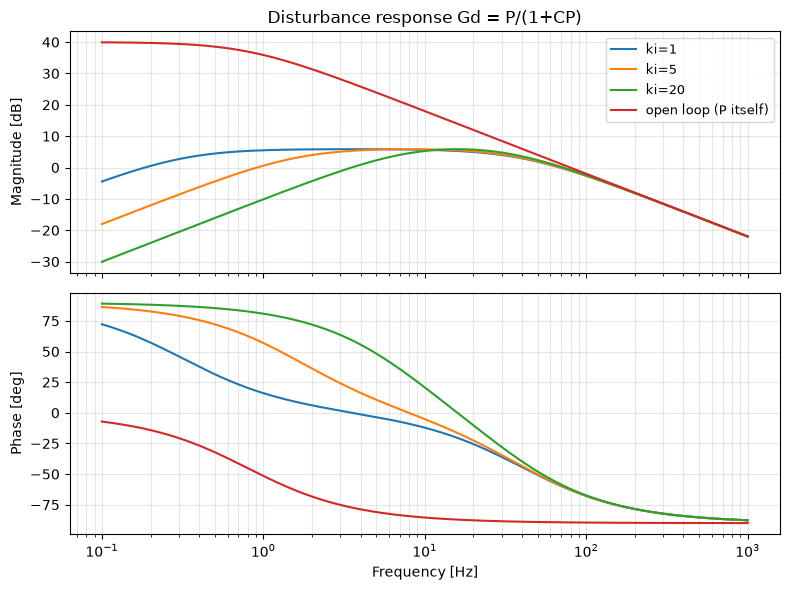

In [2]:
J, b = 0.002, 0.01
P = inertia(J=J, b=b)

f = np.logspace(-1, 3, 500)
items = []
for ki in [1, 5, 20]:
    C = pi(kp=0.5, ki=ki)
    Gd = ct.feedback(P, C)          # 擾動 -> 速度
    items.append((f'ki={ki}', Gd))
items.append(('open loop (P itself)', P))
fig, (axm, axp) = bode_compare(items, f_hz=f, title='Disturbance response Gd = P/(1+CP)')
plt.show()

低頻段 $|G_d| \approx s/k_i$(斜率 +20 dB/dec):**ki 每加 10 倍,低頻擾動抑制多 20 dB**。
中頻峰值出現在迴路頻寬附近 —— 那裡回授幫不上忙。

## 時域:階躍負載擾動

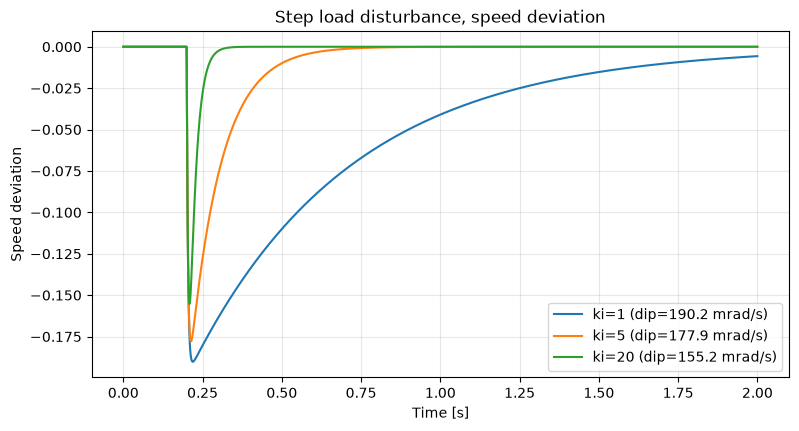

max dip by ki: {1: 0.1902, 5: 0.1779, 20: 0.1552}


In [3]:
t = np.linspace(0, 2, 4000)
d = np.where(t >= 0.2, -0.1, 0.0)       # -0.1 Nm 負載
plt.figure(figsize=(9, 4.5))
dips = {}
for ki in [1, 5, 20]:
    C = pi(kp=0.5, ki=ki)
    Gd = ct.feedback(P, C)
    _, y = ct.forced_response(Gd, t, d)
    dips[ki] = float(-y.min())
    plt.plot(t, y, label=f'ki={ki} (dip={dips[ki]*1000:.1f} mrad/s)')
plt.xlabel('Time [s]'); plt.ylabel('Speed deviation'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Step load disturbance, speed deviation')
plt.show()
print('max dip by ki:', {k: round(v, 4) for k, v in dips.items()})

## 擾動解耦(Disturbance Decoupling)

若能量測(或估測)負載轉矩,直接在控制器輸出加上補償,不必等回授誤差累積。
這裡模擬「量得到但有 1 ms 延遲、增益誤差 10%」的實際情況(延遲的影響見練習 2)。

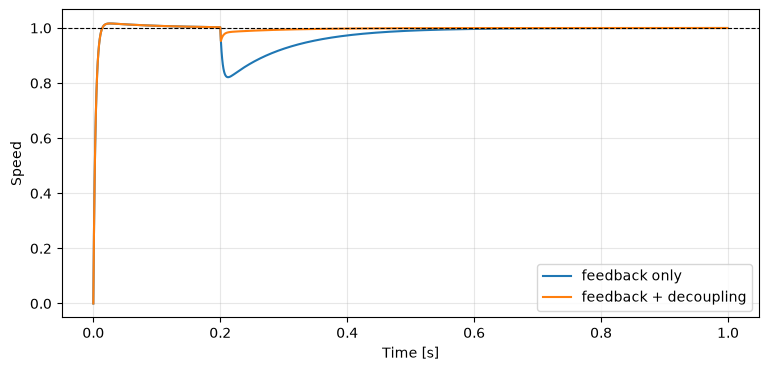

速度跌落:純回授 0.1786 | 加解耦 0.0472(改善 3.8x)


In [4]:
fs = 1000.0
dt = 1 / fs
n = int(1.0 / dt)
tt = np.arange(n) * dt
d_sig = np.where(tt >= 0.2, 0.1, 0.0)    # +0.1 Nm 負載

def run(decouple, meas_delay_ms=1, meas_gain=0.9):
    plant = MotorPlant(J=J, b=b, dt=dt)
    ctrl = DiscretePID(kp=0.5, ki=5.0, dt=dt)
    dly = Delay(int(meas_delay_ms * 1e-3 / dt))
    y = np.empty(n)
    for k in range(n):
        y[k] = plant.w
        u = ctrl.step(1.0 - plant.w)
        d_meas = dly.step(d_sig[k]) * meas_gain
        if decouple:
            u += d_meas                 # 前饋補償(抵銷負載轉矩)
        plant.step(u, t_dist=d_sig[k])
    return y

y_fb = run(False)
y_dc = run(True)
plt.figure(figsize=(9, 4))
plt.plot(tt, y_fb, label='feedback only')
plt.plot(tt, y_dc, label='feedback + decoupling')
plt.axhline(1, color='k', ls='--', lw=0.8)
plt.xlabel('Time [s]'); plt.ylabel('Speed'); plt.legend(); plt.grid(alpha=0.3)
plt.show()
dip_fb = float(1 - y_fb[int(0.2/dt):].min())
dip_dc = float(1 - y_dc[int(0.2/dt):].min())
print(f'速度跌落:純回授 {dip_fb:.4f} | 加解耦 {dip_dc:.4f}(改善 {dip_fb/dip_dc:.1f}x)')

In [5]:
# ✅ 驗證
assert dips[1] > dips[5] > dips[20]                     # ki 越大跌落越小(峰值差異有限)
# 低頻抑制才是 ki 的主戰場:|Gd(0.1 Hz)| 應相差 20*log10(20) ≈ 26 dB
g1 = frf_of_system(ct.feedback(P, pi(0.5, 1)), [0.1])['mag_db'][0]
g20 = frf_of_system(ct.feedback(P, pi(0.5, 20)), [0.1])['mag_db'][0]
assert abs((g1 - g20) - 20 * np.log10(20)) < 2
# 低頻 |Gd| 與 s/ki 漸近線吻合(取 0.1 Hz)
asym = 20 * np.log10(2 * np.pi * 0.1 / 20)
assert abs(g20 - asym) < 1.5
assert dip_dc < dip_fb / 2                              # 解耦至少改善 2 倍
print('Ch7 驗證通過 ✅')

Ch7 驗證通過 ✅


## 練習
1. 畫 dip 對 ki 的 log-log 圖,驗證低頻段斜率。
2. 解耦路徑的量測延遲加到 50 ms,還有效嗎?什麼頻率以上的擾動反而被放大?
3. 對正弦擾動(5 Hz、40 Hz、200 Hz)分別模擬,對照 $|G_d(f)|$ 的預測值。
4. 第 10 章的觀測器可以估測負載轉矩 —— 先想想結構,學完再回來實作。